In [39]:
import pandas as pd

# Define the file path
csv_file_path_fix = 'dataset/price_emas_fix.csv'

# Read the CSV file into a DataFrame
price_emas_fix_df = pd.read_csv(csv_file_path_fix)

# Keep only the first two columns
price_emas_fix_df = price_emas_fix_df.iloc[:, :2]

# Extract the price data from the 'time;price' column
price_emas_fix_df['price'] = price_emas_fix_df['time;price'].str.extract(r'(\d+)]')

# Extract the time data from the 'time;price' column
price_emas_fix_df['time'] = price_emas_fix_df['time;price'].str.extract(r'\[(\d+)')

# Drop the original 'time;price' column
price_emas_fix_df.drop(columns=['time;price'], inplace=True)

# Move the 'price' column up by one row
price_emas_fix_df['price'] = price_emas_fix_df['price'].shift(-1)

# Display the first few rows of the updated DataFrame
price_emas_fix_df.head()

# Remove rows with missing values in 'price' or 'time' columns
price_emas_fix_df.dropna(subset=['price', 'time'], inplace=True)

# Display the first few rows of the updated DataFrame
price_emas_fix_df.head()

,price,time
0,408000,1262596020000
2,410000,1262683680000
4,410000,1262761260000
6,412000,1262857500000
8,410000,1262943420000


In [40]:
# Convert the 'time' column from Unix timestamp to datetime
price_emas_fix_df['time'] = pd.to_datetime(price_emas_fix_df['time'], unit='ms')

# Extract only the date, month, and year
price_emas_fix_df['date'] = price_emas_fix_df['time'].dt.date
price_emas_fix_df['month'] = price_emas_fix_df['time'].dt.month
price_emas_fix_df['year'] = price_emas_fix_df['time'].dt.year

# Display the first few rows of the updated DataFrame
price_emas_fix_df.head()
price_emas_fix_df.to_csv('dataset/price_emas_fix_final.csv', index=False)

C:\Users\hisbi\AppData\Local\Temp\ipykernel_632\715556365.py:2: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  price_emas_fix_df['time'] = pd.to_datetime(price_emas_fix_df['time'], unit='ms')


# 1 Buka Dataset Final

In [42]:
# Define the file path
csv_file_path_final = 'dataset/price_emas_fix_final.csv'

# Read the CSV file into a DataFrame
price_emas_fix_final_df = pd.read_csv(csv_file_path_final)

# Select only the 'price' and 'date' columns
price_emas_fix_final_df = price_emas_fix_final_df[['price', 'date']]

# Display the first few rows of the DataFrame
price_emas_fix_final_df.head()

,price,date
0,408000,2010-01-04
1,410000,2010-01-05
2,410000,2010-01-06
3,412000,2010-01-07
4,410000,2010-01-08


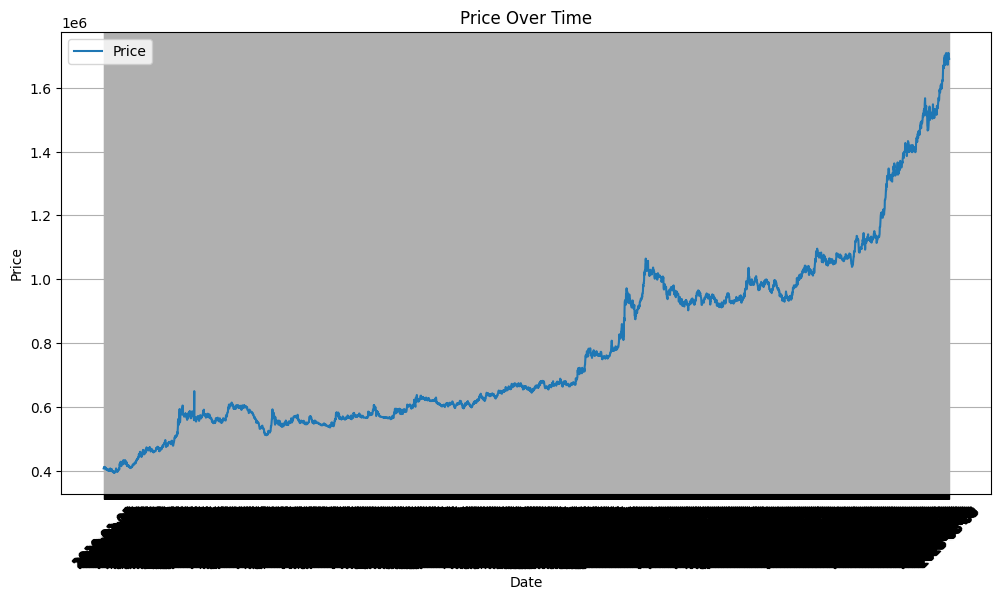

In [43]:
import matplotlib.pyplot as plt

# Plot the price over time
plt.figure(figsize=(12, 6))
plt.plot(price_emas_fix_final_df['date'], price_emas_fix_final_df['price'], label='Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()